In [1]:
# Instalação do TensorFlow
!pip install tensorflow
import tensorflow as tf
print(tf.__version__)

2.20.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model

In [4]:
# Carregamento dos dados
cifar10 = tf.keras.datasets.cifar10
# Separacao dos dados de treino e teste
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# Normalizacao dos dados de treino
x_train, x_test = x_train / 255.0, x_test / 255.0
# Transformando os dados de respostas em vetor unidimensional
y_train, y_test = y_train.flatten(), y_test.flatten()
print("x_train.shape: ", x_train.shape)
print("y_train.shape: ", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1163s 7us/step
x_train.shape:  (50000, 32, 32, 3)
y_train.shape:  (50000,)


In [5]:
# Quantidade de classes
X = len(set(y_train))
print("number of classes: ", X)

number of classes:  10


In [6]:
# Construcao do modelo
i = Input(shape=x_train[0].shape)
# x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
# x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
# x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
# Normaliza a saida da camada de convolucao
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
# Reducao do mapa de caracteristicas usando uma janela 2x2
x = MaxPooling2D((2, 2))(x)
# x = Dropout(0.2)(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
# x = Dropout(0.2)(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
# x = Dropout(0.2)(x)

# x = GlobalMaxPooling2D()(x)
# Tranformacao para um vetor unidimensional
x = Flatten()(x)
# Desliga aleatoriamente 20% dos neuronios
x = Dropout(0.2)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
# softmax vai transforma o vetor em uma dist de probabilidade
x = Dense(X, activation='softmax')(x)

model = Model(i, x)

In [7]:
# Compila o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [8]:
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.4380 - loss: 1.7950 - val_accuracy: 0.5419 - val_loss: 1.2812
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.5743 - loss: 1.2139 - val_accuracy: 0.5159 - val_loss: 1.4051
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6318 - loss: 1.0626 - val_accuracy: 0.5811 - val_loss: 1.2235
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6748 - loss: 0.9382 - val_accuracy: 0.6461 - val_loss: 1.0657
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7061 - loss: 0.8476 - val_accuracy: 0.6719 - val_loss: 0.9732
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7374 - loss: 0.7526 - val_accuracy: 0.6714 - val_loss: 1.0432
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7586 - loss: 0.6953 - val_accuracy: 0.6039 - val_loss: 1.8629
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.7763 -

In [13]:
# Treino com aumento de dados (data augmentation)
batch_size = 32
# a parte do data_generator, ele não mostra no video, só consegui escrever até está parte
# Deduzi que deve ter horizontal_flip e vertical_flip = True
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, vertical_flip=True)
train_generator = data_generator.flow(x_train, y_train, batch_size)
steps_per_epoch = x_train.shape[0] // batch_size
# Também só deu para ver até o epoch..., como mais para baixo no vídeo mostrar n/50, deduzi que fosse 50
r = model.fit(train_generator, validation_data=(x_test, y_test), steps_per_epoch=steps_per_epoch, epochs=50)

Epoch 1/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.4459 - loss: 1.5655 - val_accuracy: 0.6553 - val_loss: 1.2358
Epoch 2/50
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.5938 - loss: 1.2262

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 2s 977us/step - accuracy: 0.5938 - loss: 1.2262 - val_accuracy: 0.6557 - val_loss: 1.2201
Epoch 3/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.5415 - loss: 1.2949 - val_accuracy: 0.6599 - val_loss: 1.0451
Epoch 4/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 879us/step - accuracy: 0.5625 - loss: 1.3027 - val_accuracy: 0.6586 - val_loss: 1.0424
Epoch 5/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.5766 - loss: 1.2086 - val_accuracy: 0.6582 - val_loss: 1.0218
Epoch 6/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 868us/step - accuracy: 0.4375 - loss: 1.3605 - val_accuracy: 0.6605 - val_loss: 1.0175
Epoch 7/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.5944 - loss: 1.1581 - val_accuracy: 0.6703 - val_loss: 0.9840
Epoch 8/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 874us/step - accuracy: 0.5938 - loss: 1.2604 - val_accuracy: 0.6702 - val_loss: 0.9849
Epoch 9/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 70s 31ms/step - accuracy: 0.6077 - loss: 1.12

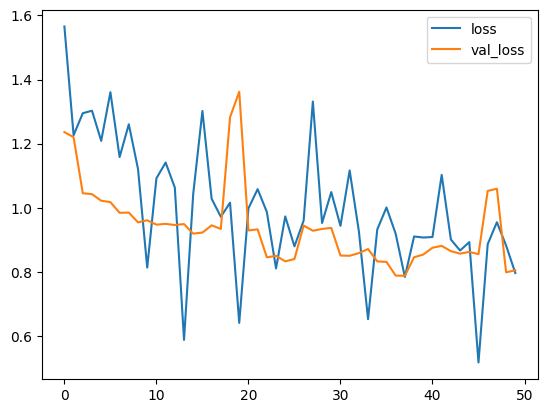

In [14]:
# Plota um grafico com a perda por iteracoes
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

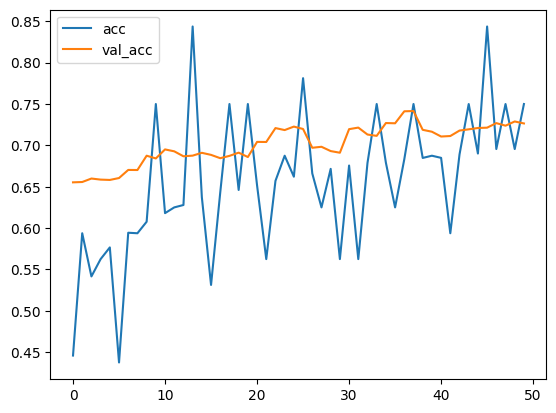

In [15]:
# Plota um grafico com a acuracia por iteracoes
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Confusion matrix, without normalization
[[893  13  20   7   5   1   5   6  35  15]
 [ 26 874   0   7   2   0   6   1  22  62]
 [119   6 457 117  95  31 108  34  20  13]
 [ 46   9  22 620  58  87  81  41  12  24]
 [ 54   2  57  85 582  14  91  99   8   8]
 [ 23   9  17 275  51 515  30  59  11  10]
 [ 12   7  31  67  17   6 846   4   8   2]
 [ 31   2   9  55  40  22   6 820   8   7]
 [108  23   5   8   3   3   2   2 818  28]
 [ 47  50   4  21   1   0   2  10  25 840]]


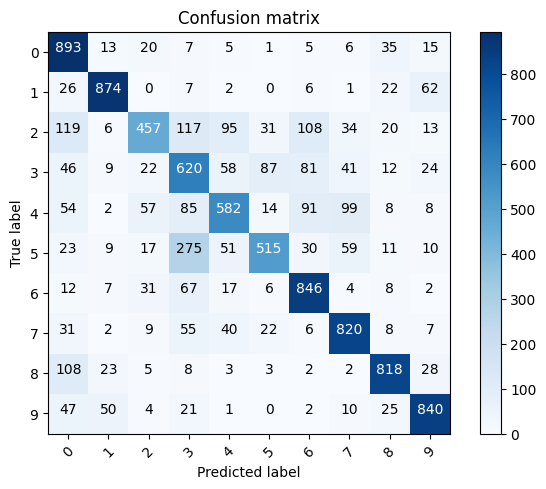

In [16]:
# Controi a matriz de confusao
from sklearn.metrics import confusion_matrix
import itertools

# funcao para plotar a matriz
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    '''
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting 'normalize=True'.
    '''
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalize confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [17]:
# label mapping
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

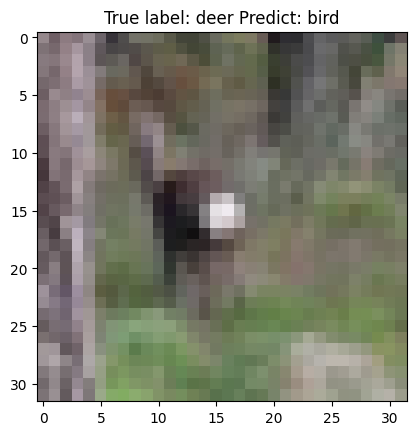

In [18]:
# show some misclassified examples
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i], cmap='gray')
plt.title("True label: %s Predict: %s" % (labels[y_test[i]], labels[p_test[i]]));

In [19]:
# Config do modelo
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    33,555,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,152,672 (385.87 MB)

 Trainable params: 33,717,386 (128.62 MB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 67,434,774 (257.24 MB)